In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score,recall_score
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier 
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler

In [2]:
df=pd.read_csv("retail_customer.csv")

In [3]:
df.head()

,customer_id,age,annual_income,months_active,avg_monthly_spend,purchase_frequency,avg_order_value,discount_usage_rate,return_rate,browsing_time_minutes,support_interactions,payment_method,region,customer_segment
0,33554,53,100473.211709,63,121.430565,0.817268,66.820403,0.117256,0.023144,77.298393,2.0,Card,Semi-Urban,Occasional
1,9428,54,54730.644845,67,572.552674,3.176551,137.087449,0.261647,0.429054,92.132565,2.0,Wallet,Urban,Occasional
2,200,44,58268.121079,57,266.593896,2.713168,71.796888,0.284785,0.011854,155.194768,1.0,UPI,Rural,Occasional
3,12448,54,64829.795654,40,691.452358,5.553977,105.501185,0.104832,0.399686,113.917756,0.0,Wallet,Rural,High_Value
4,39490,28,27431.467873,15,832.664792,1.348389,354.568534,0.409204,0.039517,50.123656,1.0,Card,Semi-Urban,Occasional


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   customer_id            50000 non-null  int64  
 1   age                    50000 non-null  int64  
 2   annual_income          46925 non-null  float64
 3   months_active          50000 non-null  int64  
 4   avg_monthly_spend      47480 non-null  float64
 5   purchase_frequency     48021 non-null  float64
 6   avg_order_value        50000 non-null  float64
 7   discount_usage_rate    47451 non-null  float64
 8   return_rate            47513 non-null  float64
 9   browsing_time_minutes  46066 non-null  float64
 10  support_interactions   48012 non-null  float64
 11  payment_method         50000 non-null  object 
 12  region                 50000 non-null  object 
 13  customer_segment       50000 non-null  object 
dtypes: float64(8), int64(3), object(3)
memory usage: 5.3+ 

In [5]:
df.describe()

,customer_id,age,annual_income,months_active,avg_monthly_spend,purchase_frequency,avg_order_value,discount_usage_rate,return_rate,browsing_time_minutes,support_interactions
count,50000.000000,50000.000000,46925.000000,50000.000000,47480.000000,48021.000000,50000.000000,47451.000000,47513.000000,46066.000000,48012.000000
mean,25000.500000,44.002820,44542.620904,36.477480,337.294238,4.910841,77.375915,0.284358,0.148964,61.781329,1.494606
std,14433.901067,15.269871,30537.946035,20.787197,204.627095,3.416115,70.531793,0.159236,0.110508,41.743394,1.221280
min,1.000000,18.000000,2946.317892,1.000000,8.072298,0.017013,0.940393,0.000534,0.000050,0.236109,0.000000
25%,12500.750000,31.000000,24373.244554,18.000000,192.074544,2.456867,32.018468,0.160497,0.063938,31.082283,1.000000
50%,25000.500000,44.000000,36787.730010,36.000000,297.477404,4.158673,56.600351,0.262591,0.123628,52.679175,1.000000
75%,37500.250000,57.000000,55497.245522,55.000000,439.112361,6.526903,98.832037,0.387640,0.209612,82.549571,2.000000
max,50000.000000,70.000000,530788.317921,72.000000,3026.342238,67.682528,1289.427328,0.934655,0.830395,406.813006,9.000000


In [6]:
df.columns

Index(['customer_id', 'age', 'annual_income', 'months_active',
       'avg_monthly_spend', 'purchase_frequency', 'avg_order_value',
       'discount_usage_rate', 'return_rate', 'browsing_time_minutes',
       'support_interactions', 'payment_method', 'region', 'customer_segment'],
      dtype='object')

In [7]:
df.isna().sum()

customer_id                 0
age                         0
annual_income            3075
months_active               0
avg_monthly_spend        2520
purchase_frequency       1979
avg_order_value             0
discount_usage_rate      2549
return_rate              2487
browsing_time_minutes    3934
support_interactions     1988
payment_method              0
region                      0
customer_segment            0
dtype: int64

In [8]:
num_cols = ['annual_income','avg_monthly_spend','purchase_frequency','discount_usage_rate','return_rate', 'browsing_time_minutes',
'support_interactions']
for col in num_cols:
 df[col] = df[col].fillna(df[col].median())

In [9]:
df['customer_value'] = df['avg_monthly_spend'] * df['months_active']
df['orders_per_month'] = df['purchase_frequency'] / df['months_active']
df['spend_per_order'] = df['avg_monthly_spend'] / df['purchase_frequency']
df['is_discount_lover'] = (df['discount_usage_rate'] > 0.5).astype(int)
df['high_return'] = (df['return_rate'] > 0.3).astype(int)
df['engagement'] = df['browsing_time_minutes'] * df['purchase_frequency']
df['spend_income_ratio'] = df['avg_monthly_spend'] / df['annual_income']
df['age_group'] = pd.cut(df['age'], bins=[0, 30, 45, 60, 120],labels=['Young', 'Adult', 'Mid', 'Senior'],include_lowest=True)
df['income_level'] = pd.qcut(df['annual_income'], 3,labels=['Low', 'Medium', 'High'])
df['income_spend_interaction'] = df['annual_income'] * df['avg_monthly_spend']
df['activity_spend'] = df['months_active'] * df['avg_monthly_spend']

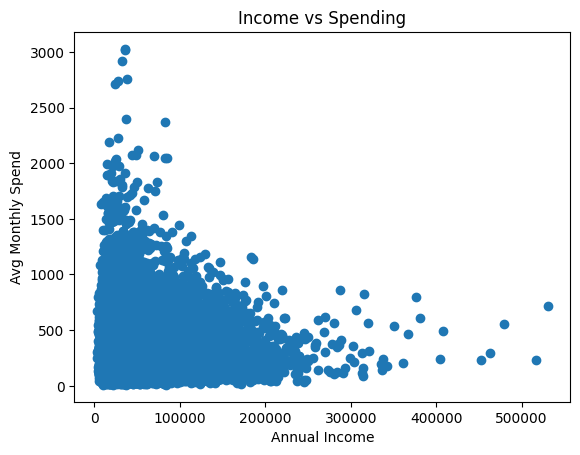

In [10]:
plt.scatter(df['annual_income'], df['avg_monthly_spend'])
plt.xlabel("Annual Income")
plt.ylabel("Avg Monthly Spend")
plt.title("Income vs Spending")
plt.show()

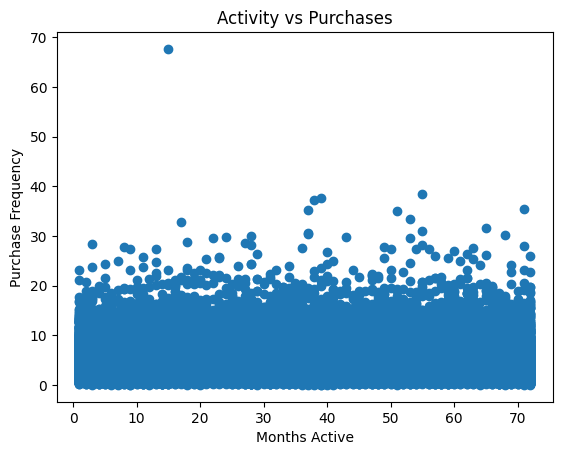

In [11]:
plt.scatter(df['months_active'], df['purchase_frequency'])
plt.xlabel("Months Active")
plt.ylabel("Purchase Frequency")
plt.title("Activity vs Purchases")
plt.show()

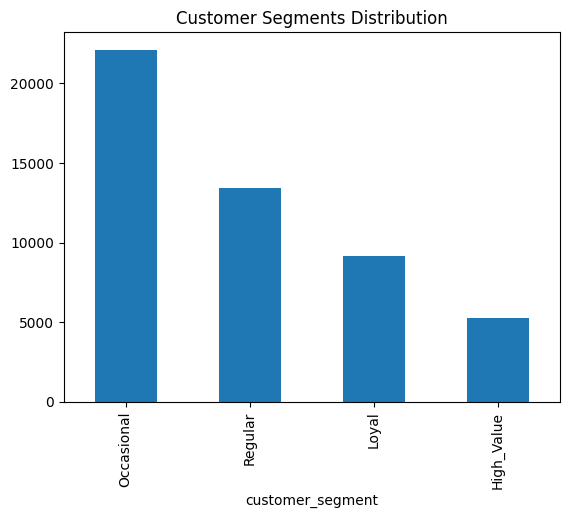

In [12]:
df['customer_segment'].value_counts().plot(kind='bar')
plt.title("Customer Segments Distribution")
plt.show()

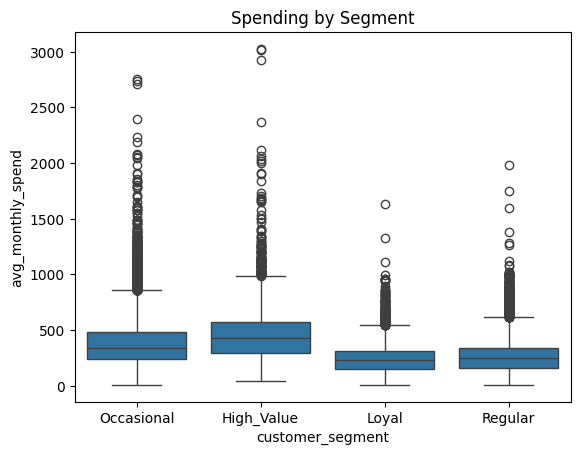

In [13]:
sns.boxplot(x='customer_segment', y='avg_monthly_spend', data=df)
plt.title("Spending by Segment")
plt.show()

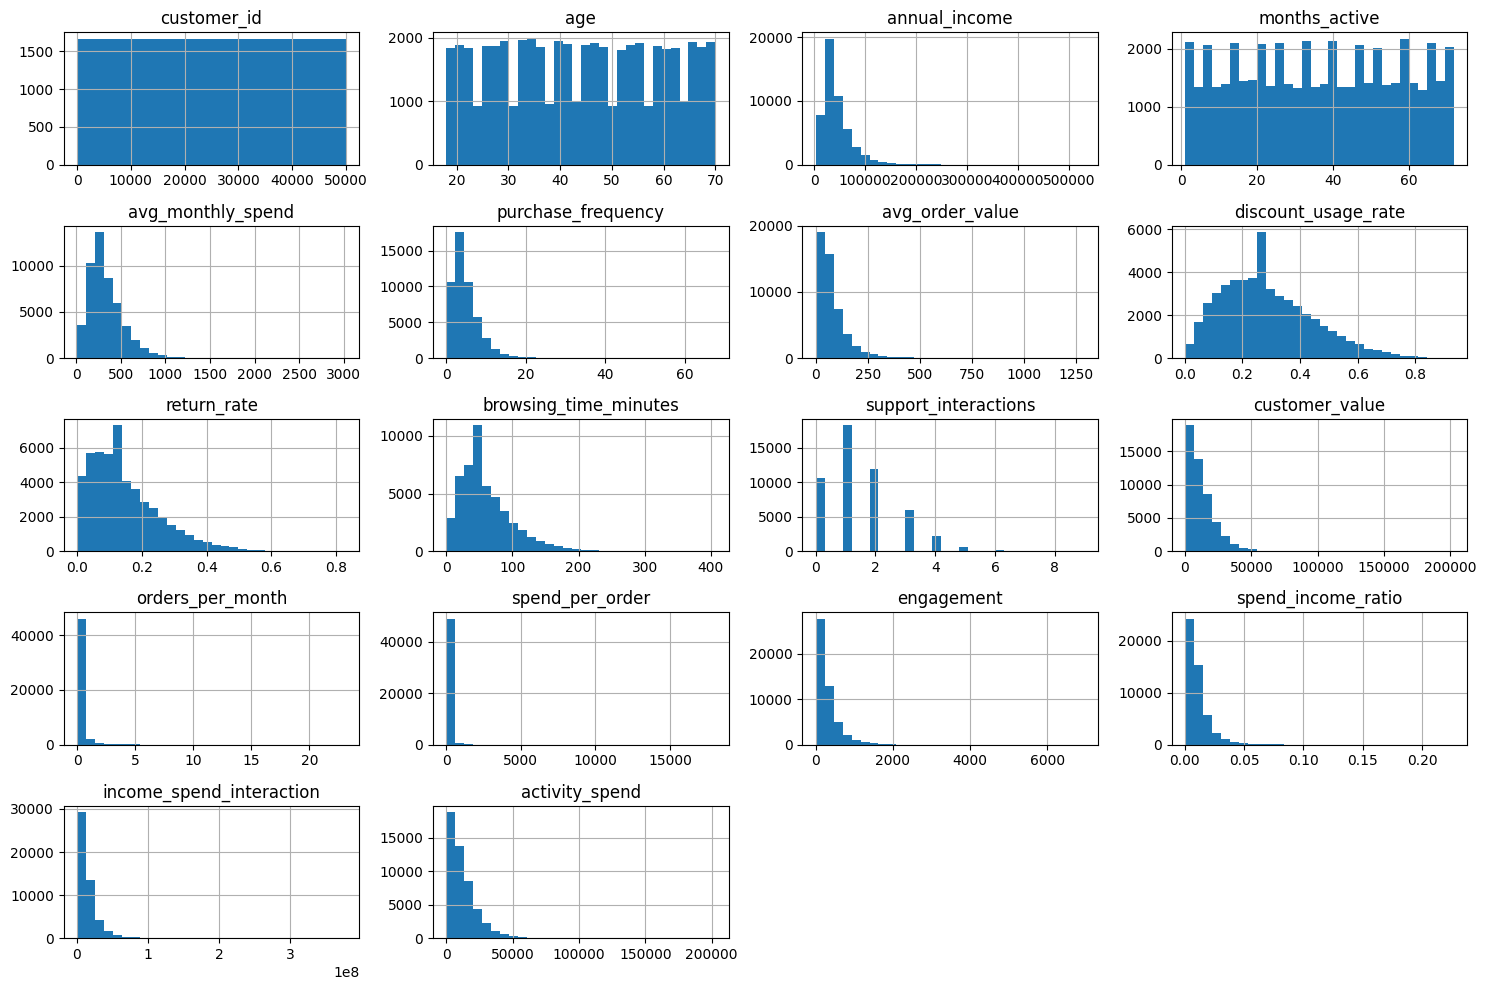

In [14]:
num_cols = df.select_dtypes(include=['int64','float64']).columns
df[num_cols].hist(figsize=(15,10), bins=30)
plt.tight_layout()
plt.show()

In [15]:
df.duplicated().sum()

0

In [16]:
df.nunique()

customer_id                 50000
age                            53
annual_income               46925
months_active                  72
avg_monthly_spend           47481
purchase_frequency          48021
avg_order_value             50000
discount_usage_rate         47451
return_rate                 47513
browsing_time_minutes       46067
support_interactions           10
payment_method                  3
region                          3
customer_segment                4
customer_value              47552
orders_per_month            48092
spend_per_order             49870
is_discount_lover               2
high_return                     2
engagement                  49856
spend_income_ratio          49825
age_group                       4
income_level                    3
income_spend_interaction    49825
activity_spend              47552
dtype: int64

In [17]:
for col in df.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))

In [18]:
df.select_dtypes(include='object').columns

Index([], dtype='object')

In [19]:
def detect_outliers_iqr(df):
    outlier_info = {}
    numeric_cols = df.select_dtypes(include='number').columns
    for col in numeric_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        outliers = df[(df[col] < lower) | (df[col] > upper)]
        outlier_info[col] = {
            'count': len(outliers),
            'percentage': round(len(outliers) / len(df) * 100, 2),
            'indices': outliers.index.tolist()
        }
    return pd.DataFrame(outlier_info).T.sort_values(by='count', ascending=False)
outlier_summary = detect_outliers_iqr(df)
print(outlier_summary)


                         count percentage  \
orders_per_month          5746      11.49   
is_discount_lover         5109      10.22   
high_return               4960       9.92   
spend_per_order           4173       8.35   
income_spend_interaction  3123       6.25   
support_interactions      3091       6.18   
engagement                3032       6.06   
spend_income_ratio        3017       6.03   
avg_order_value           2898        5.8   
annual_income             2703       5.41   
browsing_time_minutes     1901        3.8   
customer_value            1816       3.63   
activity_spend            1816       3.63   
purchase_frequency        1799        3.6   
avg_monthly_spend         1609       3.22   
return_rate               1411       2.82   
discount_usage_rate        511       1.02   
customer_id                  0        0.0   
customer_segment             0        0.0   
region                       0        0.0   
age                          0        0.0   
months_act

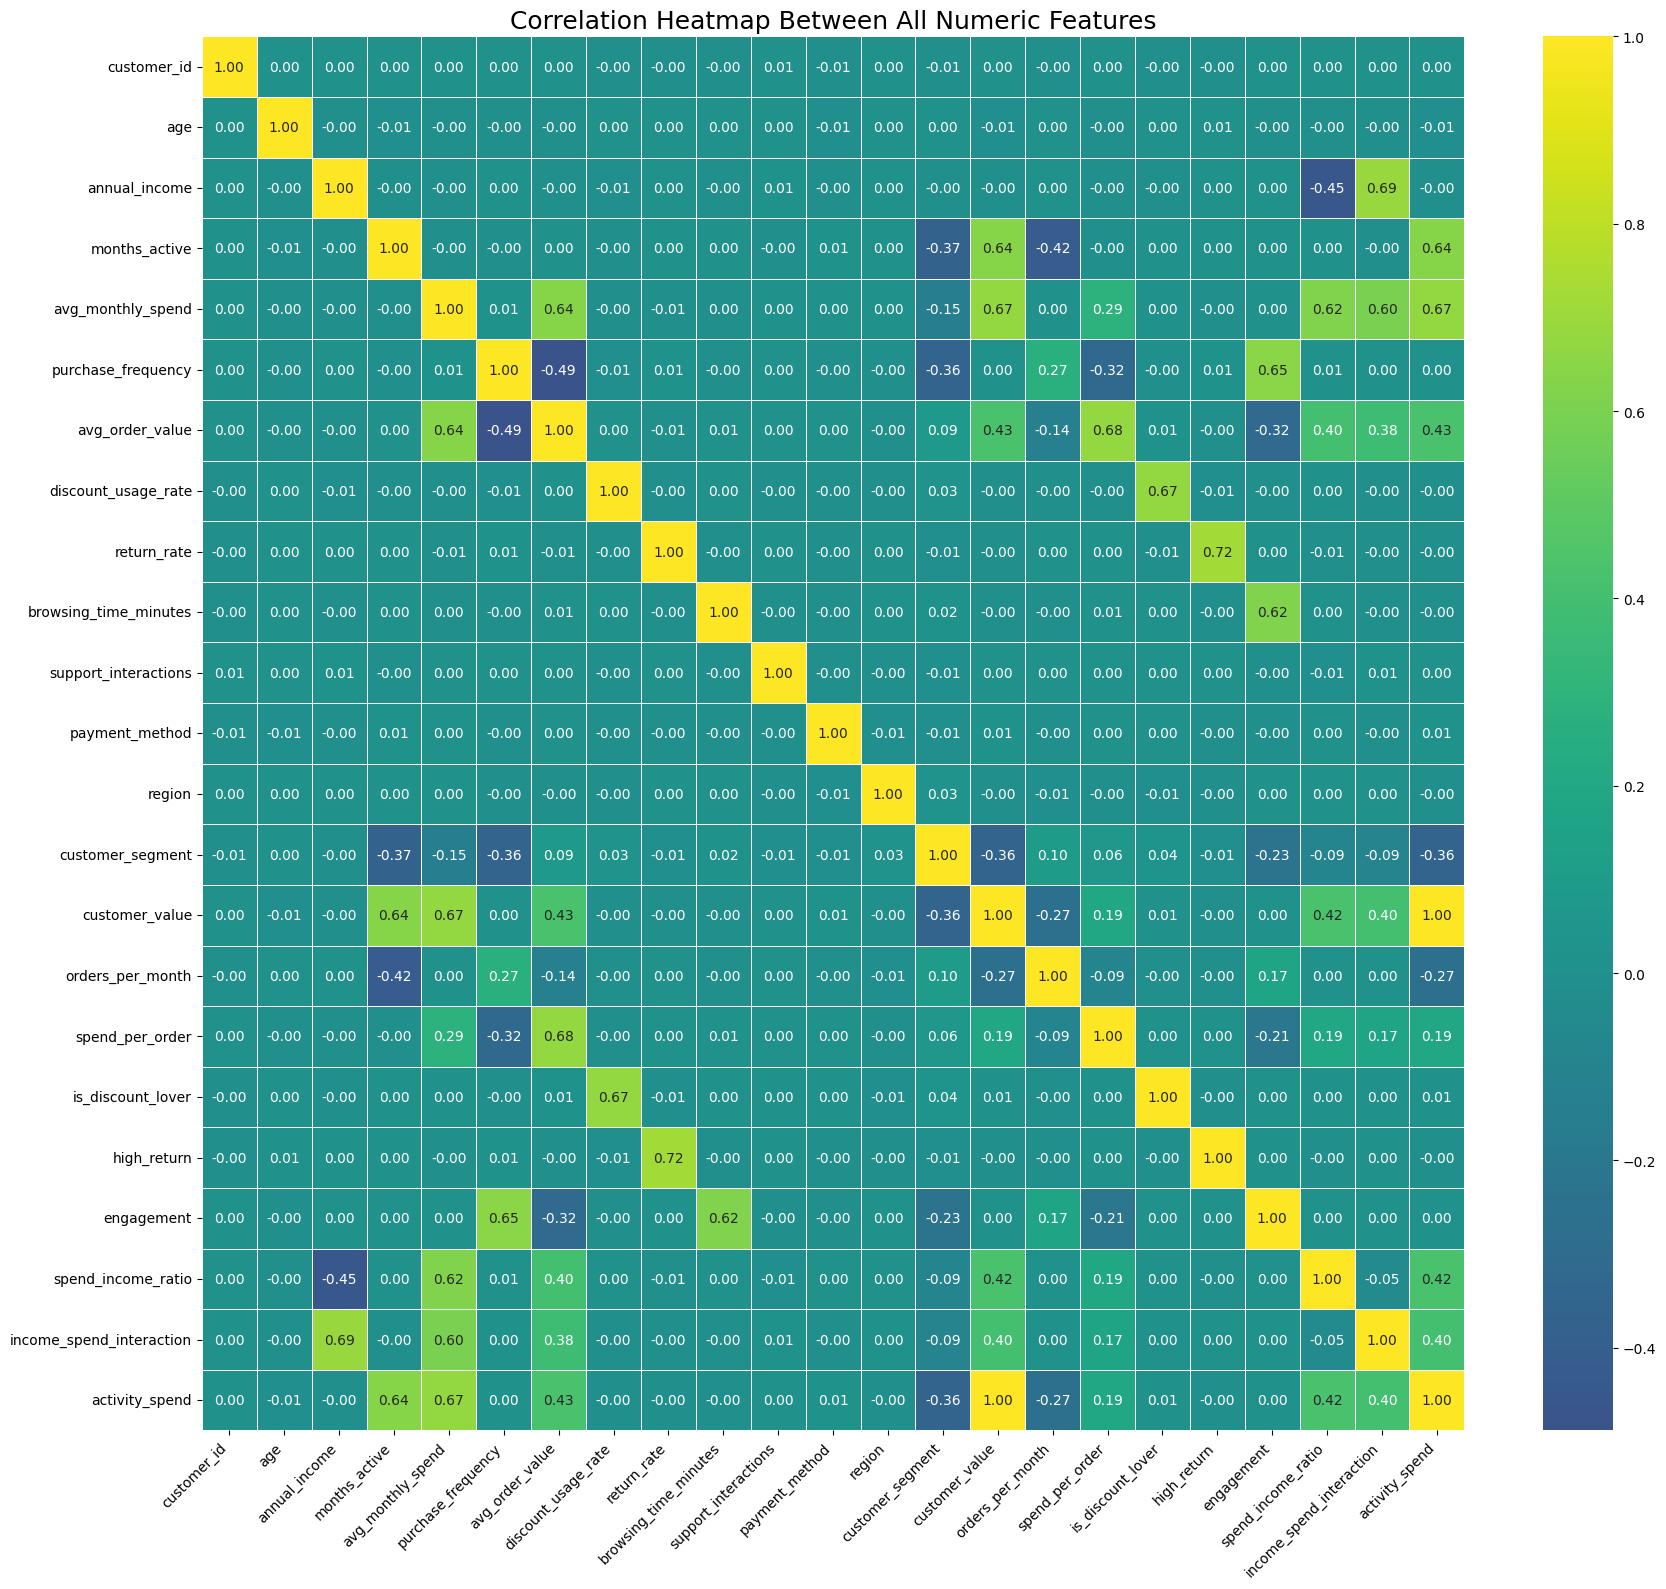

In [20]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(18, 16))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="viridis", center=0, linewidths=0.5)
plt.title("Correlation Heatmap Between All Numeric Features", fontsize=18)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [21]:
df.drop(['customer_id','customer_value','orders_per_month','spend_per_order','engagement','spend_income_ratio','income_spend_interaction',
'activity_spend'], axis=1, inplace=True)

In [22]:
X=df.drop(['customer_segment'],axis=1)
y=df['customer_segment']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [23]:
X_train.shape,X_test.shape,y_train.shape,y_test.shape

((40000, 16), (10000, 16), (40000,), (10000,))

In [24]:
y_train.value_counts(),y_test.value_counts()

(customer_segment
 2    17762
 3    10736
 1     7278
 0     4224
 Name: count, dtype: int64,
 customer_segment
 2    4347
 3    2719
 1    1885
 0    1049
 Name: count, dtype: int64)

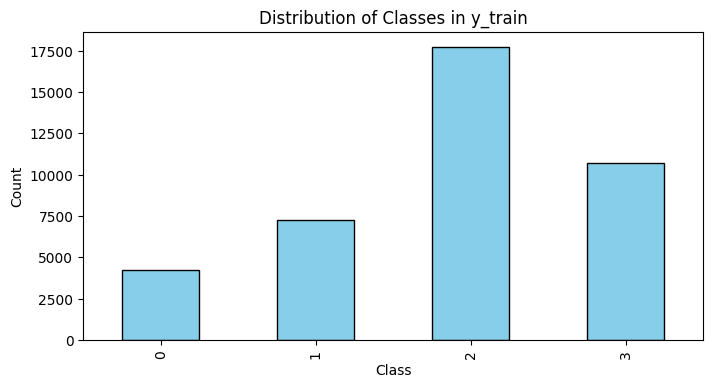

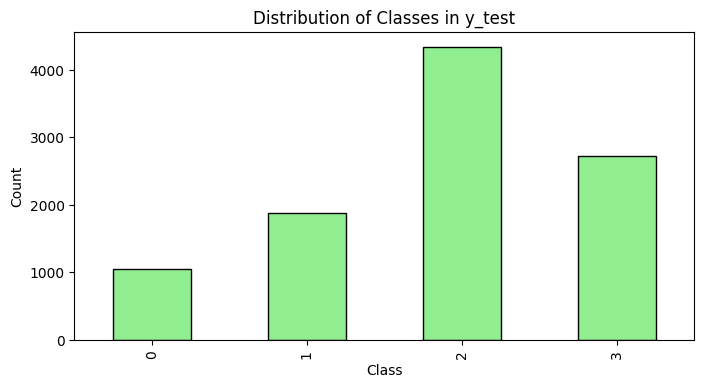

In [25]:
plt.figure(figsize=(8,4))
y_train.value_counts().sort_index().plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Distribution of Classes in y_train')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()
plt.figure(figsize=(8,4))
y_test.value_counts().sort_index().plot(kind='bar', color='lightgreen', edgecolor='black')
plt.title('Distribution of Classes in y_test')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

In [26]:
df = pd.get_dummies(df, drop_first=True)                        
# SMOTE for class balance
smote=SMOTE()
X=df.drop('customer_segment',axis=1)
y=df['customer_segment']
X_smote,y_smote=smote.fit_resample(X,y)

In [27]:
X_train,X_test,y_train,y_test=train_test_split(X_smote,y_smote,test_size=0.2,random_state=42)

In [28]:
y_train.value_counts(),y_test.value_counts()

(customer_segment
 3    17733
 1    17721
 0    17654
 2    17640
 Name: count, dtype: int64,
 customer_segment
 2    4469
 0    4455
 1    4388
 3    4376
 Name: count, dtype: int64)

In [29]:
#DecisionTreeClassifier
clf= DecisionTreeClassifier()
clf =clf.fit(X_train,y_train)

[Text(0.49233266040875506, 0.9852941176470589, 'x[4] <= 4.161\ngini = 0.75\nsamples = 70748\nvalue = [17654, 17721, 17640, 17733]'),
 Text(0.2431929459614439, 0.9558823529411765, 'x[5] <= 90.097\ngini = 0.554\nsamples = 25070\nvalue = [716.0, 1071.0, 13563.0, 9720.0]'),
 Text(0.36776280318509946, 0.9705882352941178, 'True  '),
 Text(0.12640204451647752, 0.9264705882352942, 'x[2] <= 28.5\ngini = 0.572\nsamples = 14016\nvalue = [418, 860, 5358, 7380]'),
 Text(0.03987977677827619, 0.8970588235294118, 'x[5] <= 45.506\ngini = 0.533\nsamples = 5050\nvalue = [73, 123, 2661, 2193]'),
 Text(0.017607290647505644, 0.8676470588235294, 'x[8] <= 39.556\ngini = 0.527\nsamples = 2058\nvalue = [37, 62, 781, 1178]'),
 Text(0.008159649333987065, 0.8382352941176471, 'x[9] <= 1.98\ngini = 0.534\nsamples = 614\nvalue = [15, 10, 324, 265]'),
 Text(0.005203914165509426, 0.8088235294117647, 'x[9] <= 1.002\ngini = 0.524\nsamples = 385\nvalue = [8.0, 4.0, 166.0, 207.0]'),
 Text(0.0030328030087284834, 0.779411764

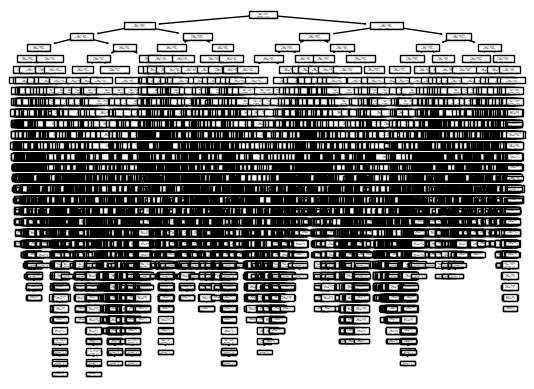

In [30]:
tree.plot_tree(clf)

In [31]:
#Feature Importance Analysis
importances = clf.feature_importances_
feature_importance = pd.Series(importances, index=X_train.columns)
important_features = feature_importance.sort_values(ascending=False)
print(important_features.head(10))

purchase_frequency       0.256773
months_active            0.180881
avg_monthly_spend        0.152799
avg_order_value          0.107638
browsing_time_minutes    0.053384
annual_income            0.045602
discount_usage_rate      0.044912
return_rate              0.040919
age                      0.037170
support_interactions     0.032687
dtype: float64


In [32]:
pred_clf = clf.predict(X_test)
print("Precision:", precision_score(y_test, pred_clf, average='weighted'))
print("Recall:", recall_score(y_test, pred_clf, average='weighted'))
print("Confusion Matrix:")
print(confusion_matrix(y_test, pred_clf))

Precision: 0.7133738160328146
Recall: 0.7140999547715966
Confusion Matrix:
[[3729  499   83  144]
 [ 491 3357  107  433]
 [ 115  148 2991 1215]
 [ 171  414 1237 2554]]


In [33]:
scores = cross_val_score(clf, X, y, cv=5, scoring='accuracy')
print("Cross-Validation Accuracy:", scores.mean())

Cross-Validation Accuracy: 0.65376


In [34]:
#RandomForestClassifier
rf = RandomForestClassifier(n_estimators=100,class_weight='balanced',random_state=42,n_jobs=-1)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)

In [35]:
print('ACCuracy',accuracy_score(y_test,pred_rf))
print('Precition',precision_score(y_test,pred_rf,average='weighted'))
print('recall',recall_score(y_test,pred_rf,average='weighted'))
print('confusion_matrix',confusion_matrix(y_test,pred_rf))

ACCuracy 0.807157394843962
Precition 0.8119780487697532
recall 0.807157394843962
confusion_matrix [[3965  298   74  118]
 [ 323 3567   72  426]
 [  11   19 3481  958]
 [  29  188  895 3264]]


In [36]:
#XGBClassifier
xgb = XGBClassifier()
xgb.fit(X_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [37]:
pred_xgb= xgb.predict(X_test)
print('ACCuracy',accuracy_score(y_test,pred_xgb))
print('Precition',precision_score(y_test,pred_xgb,average='weighted'))
print('recall',recall_score(y_test,pred_xgb,average='weighted'))
print('confusion_matrix',confusion_matrix(y_test,pred_xgb))

ACCuracy 0.807157394843962
Precition 0.8112824653220532
recall 0.807157394843962
confusion_matrix [[3886  352   61  156]
 [ 330 3547   54  457]
 [  12   24 3606  827]
 [  30  207  901 3238]]


In [38]:
#SVM
svm=SVC()
svm.fit(X_train,y_train)

SVC()

In [39]:
pred_svm=svm.predict(X_test)
print('ACCuracy',accuracy_score(y_test,pred_svm))
print('Precition',precision_score(y_test,pred_svm,average='weighted'))
print('recall',recall_score(y_test,pred_svm,average='weighted'))
print('confusion_matrix',confusion_matrix(y_test,pred_svm))

ACCuracy 0.30653550429669835
Precition 0.33908011402076216
recall 0.30653550429669835
confusion_matrix [[1089 1845  234 1287]
 [ 135 2531  204 1518]
 [ 754 1990  293 1432]
 [ 260 2413  194 1509]]
